### EDA on merged dataset

Pitchfork + Resident Advisor + Critique Brainz

In [1]:
# Imports and path config for merged dataset EDA.
from pathlib import Path
import pandas as pd

DATA_DIR = Path("/Users/jamesemcnally/Documents/GitHub/critical-listener/datasets")

df = pd.read_csv(DATA_DIR / "merged_dataset.csv", low_memory=False)
print(f"Shape: {df.shape}")
print(f"\nDataset counts:")
print(df["dataset"].value_counts())
df.head(2)


Shape: (48639, 22)

Dataset counts:
dataset
pitchfork           22853
resident_advisor    15560
critique_brainz     10226
Name: count, dtype: int64


,dataset,review_id,entity_id,text,rating,album,artist,reviewer_name,reviewer_id,reviewer_type,...,source,source_url,cleaned_text,word_count,char_count,sentence_count,sentiment_score,sentiment_category,genre,ra_recommends
0,critique_brainz,60d4e2a1-53be-4ca9-9683-31db6b7cbe46,08bb6ce3-bec6-4b5e-8c6f-722e45e78fb2,I had the opportunity to attend the digital pr...,NaN,La Pluma o La Espada,Astrid Hadad,jacostamolina,70a41446-ffcf-4ebd-8892-4c3ed06f0774,Noob,...,NaN,NaN,I had the opportunity to attend the digital pr...,306,1807,12,0.202814,positive,NaN,NaN
1,critique_brainz,6424629d-e6b9-410a-8f7e-aa0a6f57951a,642b183a-3e59-3cb9-9187-aeeefa0d8818,Appetite for Destruction is still the better a...,4.0,Use Your Illusion I,Guns N’ Roses,smcamp1234,02fb8586-29e9-4023-9f9a-e659d222210f,Noob,...,NaN,NaN,Appetite for Destruction is still the better a...,76,412,5,0.214053,positive,NaN,NaN


Reviews exceeding 512-token limit: 28,086 (57.7%)

By dataset:
                  50%  90%   95%   max
dataset                               
critique_brainz   349  421   459  5472
pitchfork         618  934  1090  3591
resident_advisor  249  469   539  2847


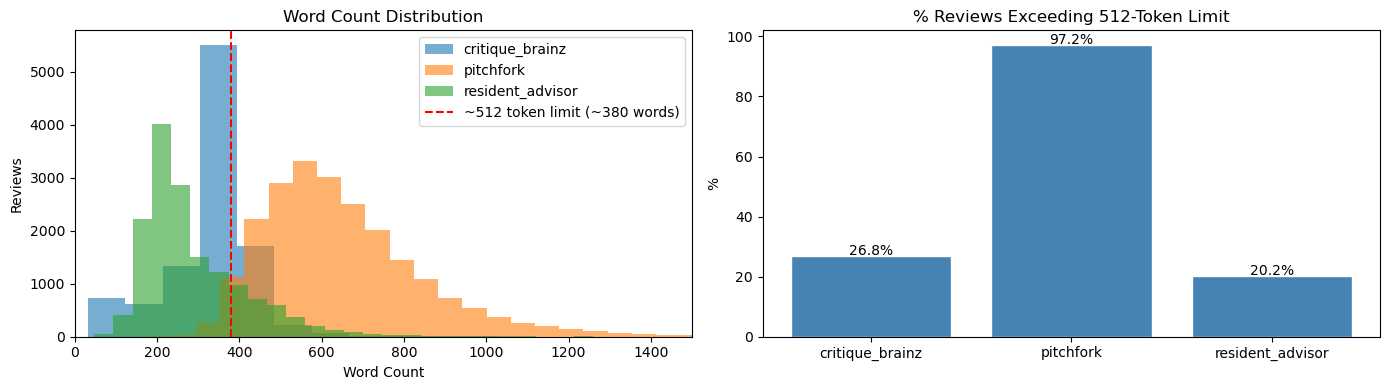

In [6]:
# Review length analysis: word count distributions and estimated 512-token truncation impact.
# Subword tokenizers average ~1.35 tokens/word, so 512 tokens ≈ 380 words.

import matplotlib.pyplot as plt

WORD_LIMIT = 380

df["est_tokens"] = (df["word_count"] * 1.35).astype(int)
truncated = df["est_tokens"] > 512

print(f"Reviews exceeding 512-token limit: {truncated.sum():,} ({truncated.mean()*100:.1f}%)")
print("\nBy dataset:")
print(df.groupby("dataset")["word_count"].describe(percentiles=[.5,.9,.95])[["50%","90%","95%","max"]].round(0).astype(int))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for name, group in df.groupby("dataset"):
    axes[0].hist(group["word_count"], bins=60, alpha=0.6, label=name)
axes[0].axvline(WORD_LIMIT, color="red", linestyle="--", label=f"~512 token limit (~{WORD_LIMIT} words)")
axes[0].set(title="Word Count Distribution", xlabel="Word Count", ylabel="Reviews", xlim=(0, 1500))
axes[0].legend()

trunc_pct = df.groupby("dataset").apply(lambda x: (x["est_tokens"] > 512).mean() * 100, include_groups=False)
axes[1].bar(trunc_pct.index, trunc_pct.values, color="steelblue", edgecolor="white")
axes[1].set(title="% Reviews Exceeding 512-Token Limit", ylabel="%")
for i, v in enumerate(trunc_pct.values):
    axes[1].text(i, v + 0.3, f"{v:.1f}%", ha="center")

plt.tight_layout()
plt.show()


Null ratings: 9,126 (18.8%)

                    count  mean   std   25%   50%  75%
dataset                                               
critique_brainz    1100.0  3.77  1.22  3.00  4.00  5.0
pitchfork         22853.0  3.53  0.61  3.25  3.65  3.9
resident_advisor  15560.0  3.69  0.50  3.50  3.70  4.0


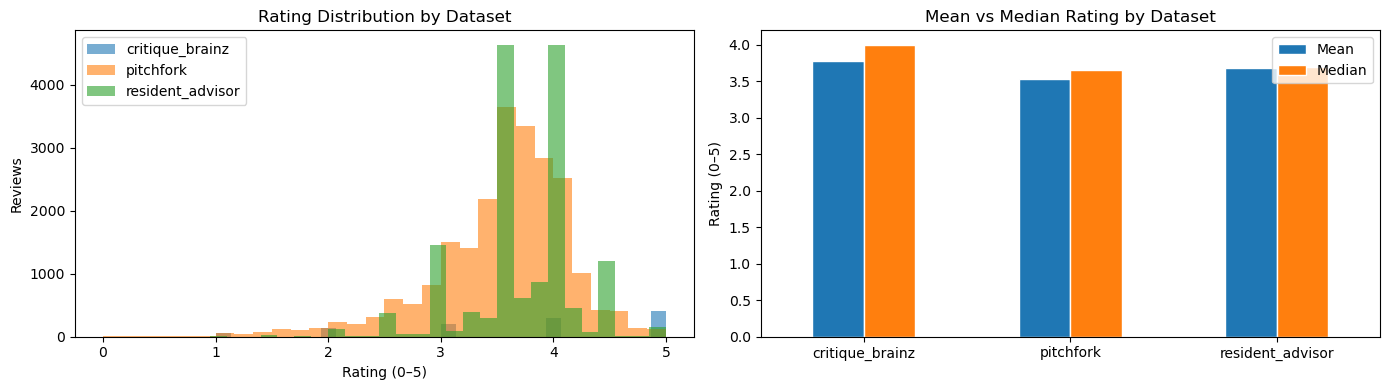

In [7]:
# Rating distributions by dataset, normalized to 0–5 scale.
# Pitchfork was originally 0–10 and halved by the consolidator.

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for name, group in df.groupby("dataset"):
    axes[0].hist(group["rating"].dropna(), bins=30, alpha=0.6, label=name)
axes[0].set(title="Rating Distribution by Dataset", xlabel="Rating (0–5)", ylabel="Reviews")
axes[0].legend()

print(f"Null ratings: {df['rating'].isna().sum():,} ({df['rating'].isna().mean()*100:.1f}%)")
print()
print(df.groupby("dataset")["rating"].describe()[["count","mean","std","25%","50%","75%"]].round(2))

stats = df.groupby("dataset")["rating"].agg(["mean","median"])
stats.plot(kind="bar", ax=axes[1], edgecolor="white")
axes[1].set(title="Mean vs Median Rating by Dataset", xlabel="", ylabel="Rating (0–5)")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(["Mean","Median"])

plt.tight_layout()
plt.show()


=== Raw ===
Unique genre tags: 61
Null / Not Listed: 13,092

=== Collapsed ===
Unique genre tags: 10


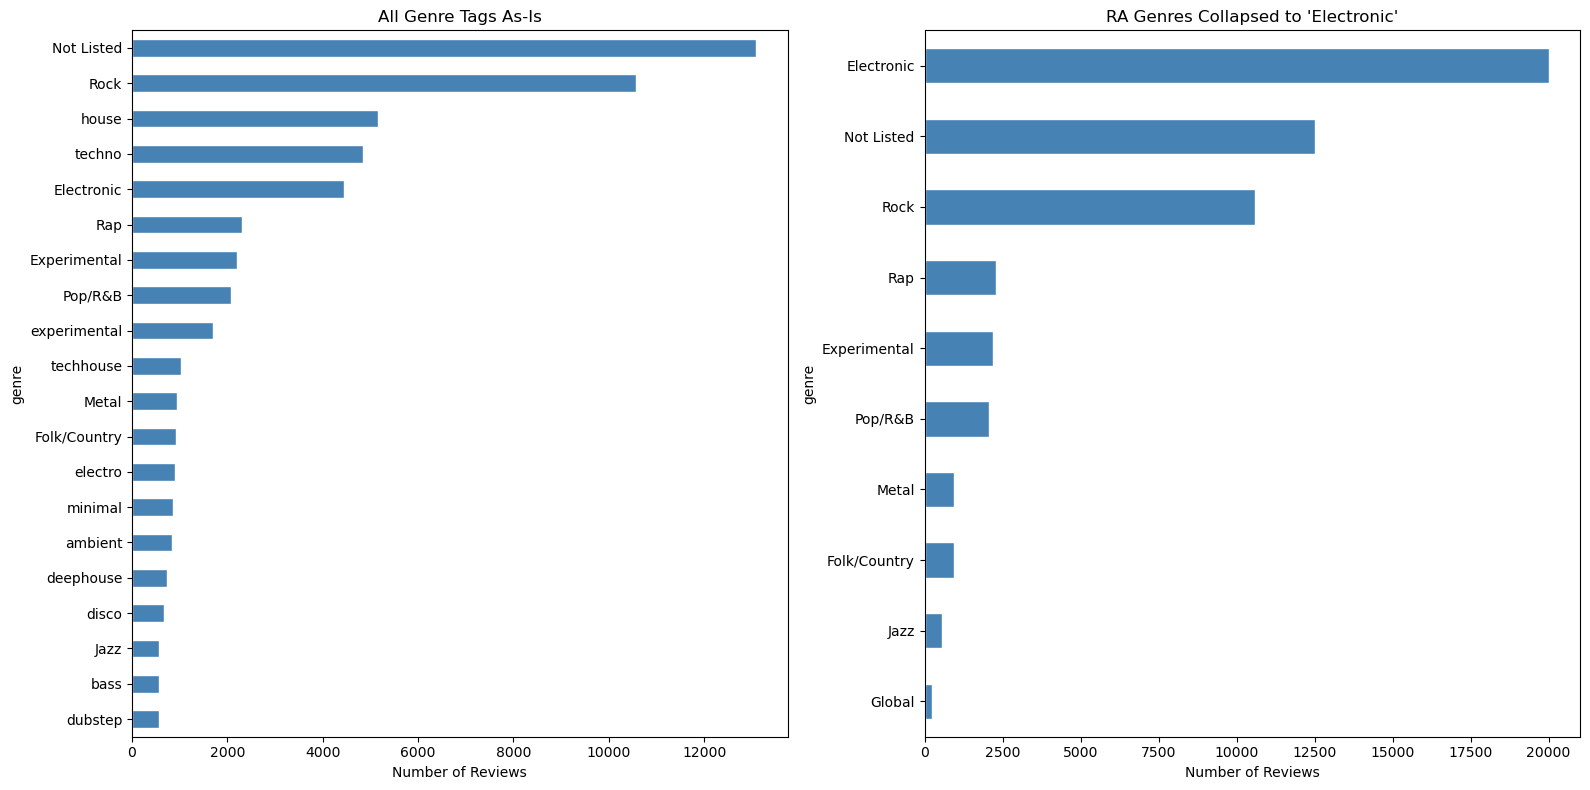

In [8]:
# Genre distribution: once with all tags as-is, once with RA genres collapsed to "Electronic".
# RA covers electronic music exclusively so its sub-genre tags (techno, house, etc.)
# are not comparable to top-level genre labels from Pitchfork and CritiqueBrainz.

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

def genre_counts(dataframe):
    return (
        dataframe["genre"].fillna("Not Listed")
        .str.split(", ")
        .explode()
        .str.strip()
        .value_counts()
    )

# Pass 1: raw genres
counts_raw = genre_counts(df)

# Pass 2: RA genres collapsed to "Electronic"
df_collapsed = df.copy()
df_collapsed.loc[df_collapsed["dataset"] == "resident_advisor", "genre"] = "Electronic"
counts_collapsed = genre_counts(df_collapsed)

for ax, counts, title in zip(axes,
    [counts_raw, counts_collapsed],
    ["All Genre Tags As-Is", "RA Genres Collapsed to 'Electronic'"]):
    counts.head(20).plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
    ax.set(title=title, xlabel="Number of Reviews")
    ax.invert_yaxis()

print("=== Raw ===")
print(f"Unique genre tags: {len(counts_raw)}")
print(f"Null / Not Listed: {df['genre'].isna().sum():,}")
print()
print("=== Collapsed ===")
print(f"Unique genre tags: {len(counts_collapsed)}")

plt.tight_layout()
plt.show()


Reviews without RA: 33,079
Unique genre tags: 10

genre
Not Listed      12519
Rock            10576
Electronic       4448
Rap              2299
Experimental     2198
Pop/R&B          2075
Metal             946
Folk/Country      932
Jazz              568
Global            224
Name: count, dtype: int64


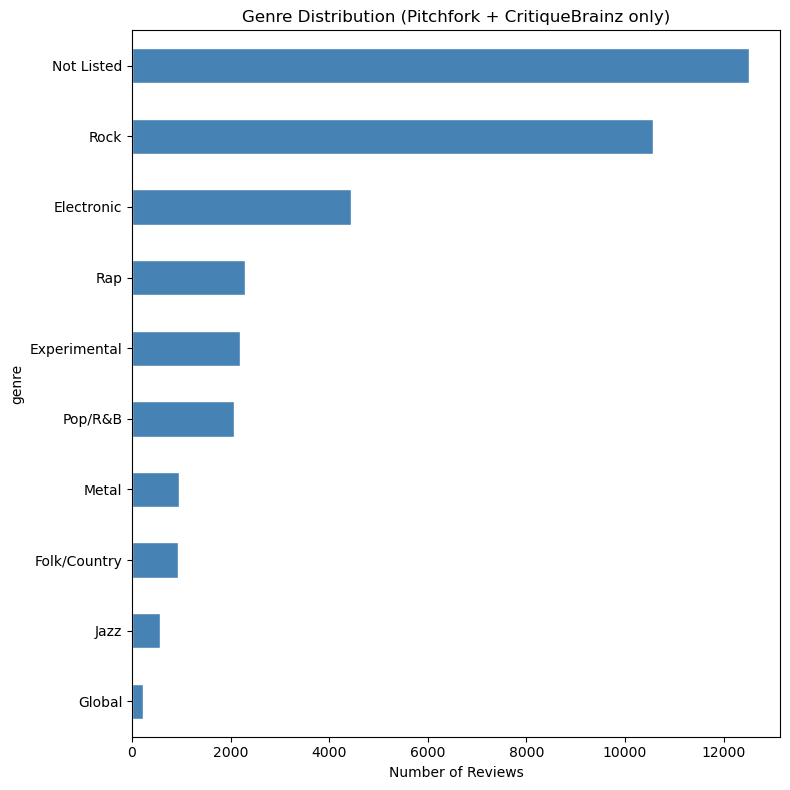

In [9]:
# Genre distribution without Resident Advisor.
df_no_ra = df[df["dataset"] != "resident_advisor"]

counts_no_ra = genre_counts(df_no_ra)
print(f"Reviews without RA: {len(df_no_ra):,}")
print(f"Unique genre tags: {len(counts_no_ra)}")
print()
print(counts_no_ra.head(15))

fig, ax = plt.subplots(figsize=(8, 8))
counts_no_ra.head(20).plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
ax.set(title="Genre Distribution (Pitchfork + CritiqueBrainz only)", xlabel="Number of Reviews")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


In [10]:
# Cross-dataset album overlap: albums reviewed in more than one source.
# Matches on normalized artist + album name. Useful for understanding dataset redundancy
# and identifying potential training pairs for fine-tuning.

df["artist_norm"] = df["artist"].str.lower().str.strip()
df["album_norm"]  = df["album"].str.lower().str.strip()

overlap = (
    df.dropna(subset=["artist_norm", "album_norm"])
    .groupby(["artist_norm", "album_norm"])["dataset"]
    .agg(list)
)

multi = overlap[overlap.apply(len) > 1]
print(f"Albums reviewed in multiple sources: {len(multi):,}")
print(f"Total unique artist/album pairs:     {overlap.shape[0]:,}")
print()
print("Source combinations:")
combos = multi.apply(lambda x: " + ".join(sorted(set(x)))).value_counts()
print(combos)
print()
print("Sample overlapping albums:")
print(multi.head(10).to_string())


Albums reviewed in multiple sources: 3,458
Total unique artist/album pairs:     44,717

Source combinations:
dataset
critique_brainz + pitchfork                       2063
pitchfork + resident_advisor                       971
critique_brainz + pitchfork + resident_advisor     180
critique_brainz                                    109
critique_brainz + resident_advisor                  79
pitchfork                                           30
resident_advisor                                    26
Name: count, dtype: int64

Sample overlapping albums:
artist_norm       album_norm            
!!!               myth takes                                  [critique_brainz, pitchfork]
1990s             cookies                                     [critique_brainz, pitchfork]
                  kicks                                       [critique_brainz, pitchfork]
2020 soundsystem  falling                              [critique_brainz, resident_advisor]
2562              fever                

                   min   max
dataset                     
critique_brainz   2001  2026
pitchfork         1999  2021
resident_advisor  2001  2019

Overall: 1999 – 2026


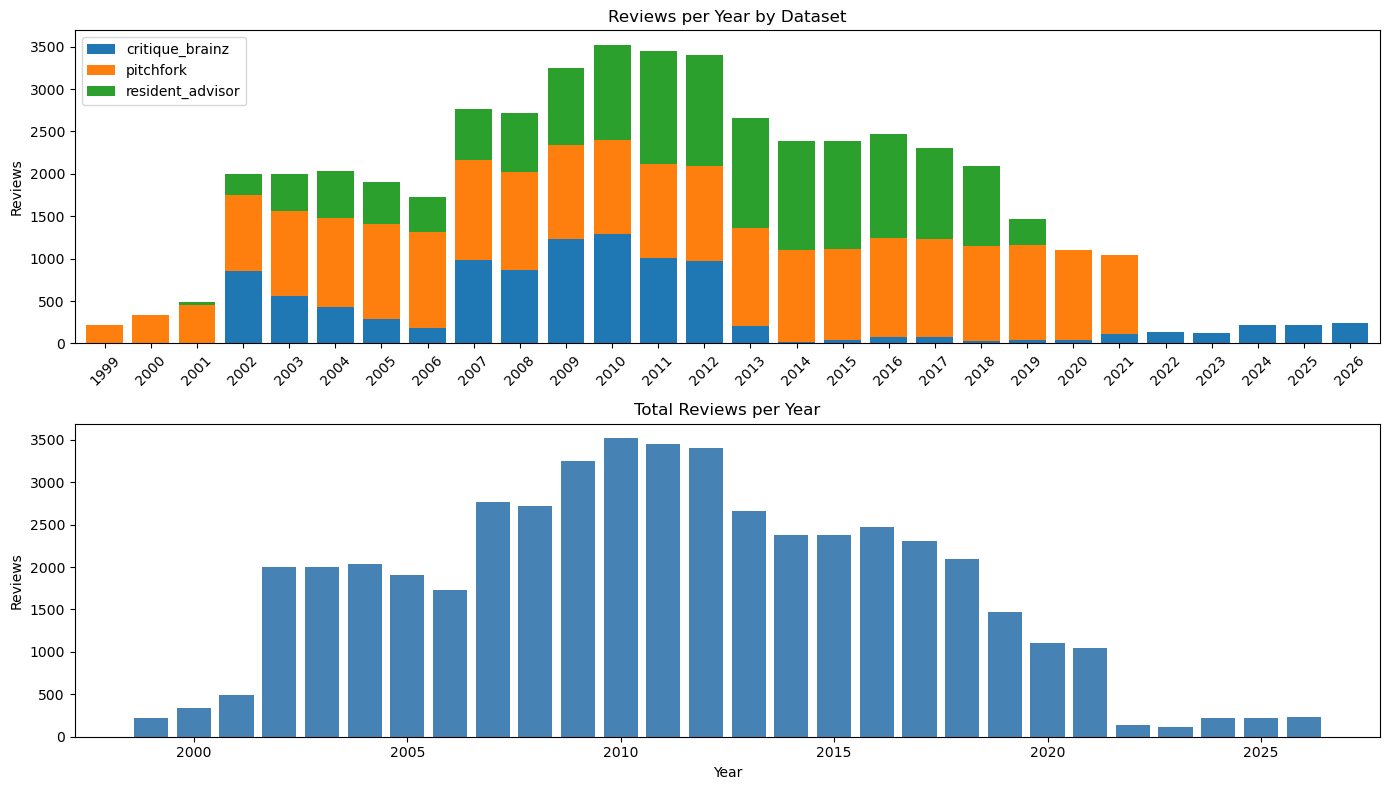

In [11]:
# Reviews per year by dataset.

df["year"] = pd.to_datetime(df["published_on"], errors="coerce").dt.year

yearly = df.groupby(["year", "dataset"]).size().unstack(fill_value=0)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Stacked bar by source
yearly.plot(kind="bar", stacked=True, ax=axes[0], edgecolor="none", width=0.8)
axes[0].set(title="Reviews per Year by Dataset", xlabel="", ylabel="Reviews")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(loc="upper left")

# Total only, with trend line
totals = yearly.sum(axis=1)
axes[1].bar(totals.index, totals.values, color="steelblue", edgecolor="none", width=0.8)
axes[1].set(title="Total Reviews per Year", xlabel="Year", ylabel="Reviews")

print(df.groupby("dataset")["year"].agg(["min","max"]))
print(f"\nOverall: {int(df['year'].min())} – {int(df['year'].max())}")

plt.tight_layout()
plt.show()


## Text-specific EDA

dataset
critique_brainz     0.283268
pitchfork           0.148690
resident_advisor    0.110524
Name: rating, dtype: float64


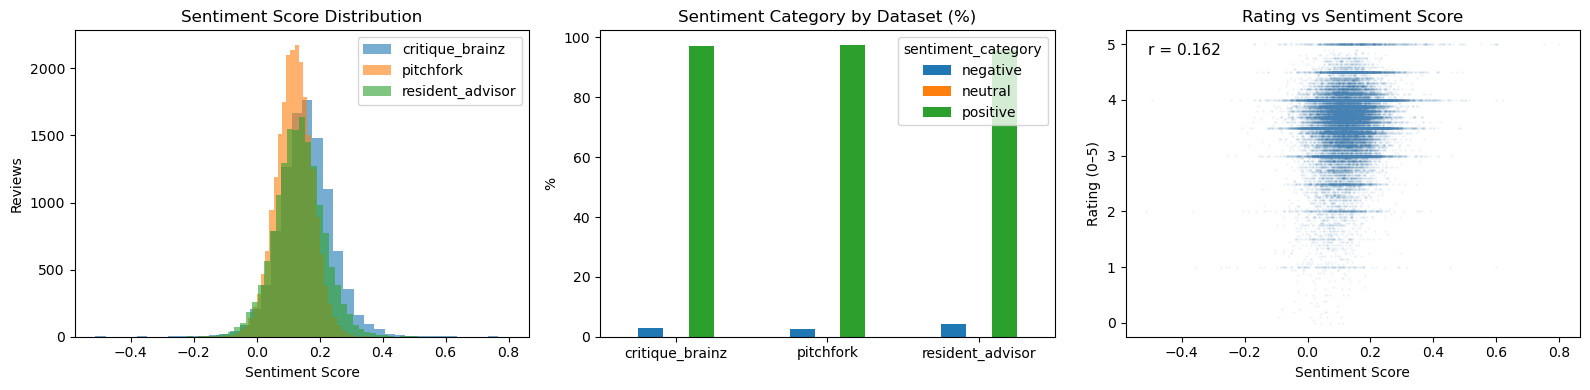

In [12]:
# Sentiment distribution across sources and correlation with ratings.

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Sentiment score distribution by dataset
for name, group in df.groupby("dataset"):
    axes[0].hist(group["sentiment_score"], bins=40, alpha=0.6, label=name)
axes[0].set(title="Sentiment Score Distribution", xlabel="Sentiment Score", ylabel="Reviews")
axes[0].legend()

# Sentiment category breakdown by dataset
sent_pct = df.groupby(["dataset","sentiment_category"]).size().unstack(fill_value=0)
sent_pct = sent_pct.div(sent_pct.sum(axis=1), axis=0) * 100
sent_pct.plot(kind="bar", ax=axes[1], edgecolor="none")
axes[1].set(title="Sentiment Category by Dataset (%)", xlabel="", ylabel="%")
axes[1].tick_params(axis="x", rotation=0)

# Rating vs sentiment
axes[2].scatter(df["sentiment_score"], df["rating"], alpha=0.05, s=1, color="steelblue")
axes[2].set(title="Rating vs Sentiment Score", xlabel="Sentiment Score", ylabel="Rating (0–5)")

corr = df[["sentiment_score","rating"]].corr().iloc[0,1]
axes[2].annotate(f"r = {corr:.3f}", xy=(0.05, 0.92), xycoords="axes fraction", fontsize=11)

print(df.groupby("dataset")[["sentiment_score","rating"]].corr().unstack()["sentiment_score"]["rating"])

plt.tight_layout()
plt.show()


##### (sentiment_score and sentiment_category don't seem very useful.)

In [14]:
# Vocabulary analysis on merged corpus: size per source and top TF-IDF terms by dataset.
# Shows what language is distinctive to each source after removing common music-review terms.

from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

music_stopwords = list(TfidfVectorizer(stop_words="english").get_stop_words()) + [
    "album", "music", "song", "songs", "track", "tracks", "sound", "sounds",
    "like", "just", "band", "new", "time", "work", "one", "make", "way",
    "record", "release", "artist", "listen", "feel", "even", "much", "well"
]

# Vocabulary size per source
for name, group in df.groupby("dataset"):
    vocab = set(" ".join(group["cleaned_text"].dropna()).lower().split())
    print(f"{name:<20} {len(vocab):,} unique tokens  |  {len(group):,} reviews")

print()

# TF-IDF top terms per dataset
corpus = df.groupby("dataset")["cleaned_text"].apply(" ".join)
vectorizer = TfidfVectorizer(max_features=10000, stop_words=music_stopwords, min_df=1)
matrix = vectorizer.fit_transform(corpus)
terms = vectorizer.get_feature_names_out()

print(f"{'Dataset':<25} Top distinctive terms")
print("-" * 90)
for i, name in enumerate(corpus.index):
    top = np.argsort(matrix[i].toarray()[0])[::-1][:12]
    print(f"{name:<25} {', '.join(terms[top])}")


critique_brainz      204,465 unique tokens  |  10,226 reviews
pitchfork            588,468 unique tokens  |  22,853 reviews
resident_advisor     250,000 unique tokens  |  15,560 reviews

Dataset                   Top distinctive terms
------------------------------------------------------------------------------------------
critique_brainz           rock, pop, love, years, guitar, best, little, good, debut, world, jazz, long
pitchfork                 rock, pop, guitar, love, years, best, don, little, voice, ve, good, long
resident_advisor          house, techno, mix, label, bass, ep, dance, vocal, synth, remix, drum, deep


In [15]:
# TF-IDF top terms by genre on the merged corpus.
# RA genres collapsed to Electronic; case-normalized; single-genre reviews only.

df["genre_clean"] = df["genre"].str.strip().str.title()
df.loc[df["dataset"] == "resident_advisor", "genre_clean"] = "Electronic"

genre_corpus = (
    df[df["genre_clean"].notna() & ~df["genre_clean"].str.contains(",", na=False)]
    .groupby("genre_clean")["cleaned_text"]
    .apply(" ".join)
)
genre_corpus = genre_corpus[genre_corpus.apply(lambda x: len(x.split())) > 500]

vectorizer = TfidfVectorizer(max_features=15000, stop_words=music_stopwords, min_df=1)
matrix = vectorizer.fit_transform(genre_corpus)
terms = vectorizer.get_feature_names_out()

print(f"{'Genre':<20} Top distinctive terms")
print("-" * 90)
for i, genre in enumerate(genre_corpus.index):
    top = np.argsort(matrix[i].toarray()[0])[::-1][:10]
    print(f"{genre:<20} {', '.join(terms[top])}")


Genre                Top distinctive terms
------------------------------------------------------------------------------------------
Electronic           house, techno, mix, bass, label, dance, ep, synth, vocal, drum
Experimental         guitar, voice, pop, piece, world, piano, long, noise, feels, rock
Folk/Country         guitar, folk, country, voice, love, sings, old, rock, life, little
Global               guitar, reggae, world, years, veloso, african, rock, love, souleyman, group
Jazz                 jazz, miles, coltrane, davis, bass, set, solo, years, playing, piano
Metal                metal, black, death, rock, guitar, ve, hardcore, long, years, bands
Pop/R&B              pop, love, voice, years, best, don, little, life, year, guitar
Rap                  rap, rapper, hop, hip, best, don, year, beats, raps, years
Rock                 rock, guitar, pop, love, years, best, ve, don, little, good


In [17]:
# Vocabulary comparison: top-rated vs bottom-rated reviews.
# High = top quartile (rating > 4.0), Low = bottom quartile (rating < 3.0).

rated = df.dropna(subset=["rating", "cleaned_text"])
high = rated[rated["rating"] >= 4.0]["cleaned_text"]
low  = rated[rated["rating"] <= 2.5]["cleaned_text"]

print(f"High-rated reviews (≥4.0): {len(high):,}")
print(f"Low-rated reviews  (≤2.5): {len(low):,}")

vec = TfidfVectorizer(max_features=15000, stop_words=music_stopwords, min_df=1)
matrix2 = vec.fit_transform([" ".join(high), " ".join(low)])
terms2 = vec.get_feature_names_out()
scores = matrix2.toarray()

print(f"\n{'HIGH-RATED top terms:'}")
print(", ".join(terms2[np.argsort(scores[0])[::-1][:15]]))
print(f"\n{'LOW-RATED top terms:'}")
print(", ".join(terms2[np.argsort(scores[1])[::-1][:15]]))


High-rated reviews (≥4.0): 11,867
Low-rated reviews  (≤2.5): 2,317

HIGH-RATED top terms:
house, rock, mix, pop, bass, guitar, years, love, label, year, best, good, vocal, techno, world

LOW-RATED top terms:
rock, pop, good, don, little, ve, love, best, really, years, guitar, doesn, better, know, house


In [18]:
# Top bigrams and trigrams across the merged corpus and by dataset.

from sklearn.feature_extraction.text import CountVectorizer

for n, label in [(2, "Bigrams"), (3, "Trigrams")]:
    vec_n = CountVectorizer(ngram_range=(n, n), stop_words="english",
                            max_features=20000, min_df=10)
    vec_n.fit(df["cleaned_text"].dropna())
    counts = np.asarray(vec_n.transform(df["cleaned_text"].dropna()).sum(axis=0)).flatten()
    top_idx = np.argsort(counts)[::-1][:12]
    ngrams = vec_n.get_feature_names_out()
    print(f"\nTop {label} (overall):")
    print(", ".join(ngrams[top_idx]))

    print(f"\nTop {label} by dataset:")
    for name, group in df.groupby("dataset"):
        mat = vec_n.transform(group["cleaned_text"].dropna())
        c = np.asarray(mat.sum(axis=0)).flatten()
        top = np.argsort(c)[::-1][:8]
        print(f"  {name:<25} {', '.join(ngrams[top])}")



Top Bigrams (overall):
sounds like, hip hop, title track, sound like, feels like, new york, dance music, feel like, debut album, tracks like, dance floor, indie rock

Top Bigrams by dataset:
  critique_brainz           title track, hip hop, sounds like, debut album, new york, sound like, second album, rock roll
  pitchfork                 sounds like, hip hop, sound like, feels like, title track, new york, feel like, indie rock
  resident_advisor          sounds like, dance floor, title track, dance music, hip hop, deep house, drum bass, 12 inch

Top Trigrams (overall):
self titled debut, new york city, yo la tengo, doesn sound like, wouldn sound place, new york times, self titled album, album title track, opening title track, broken social scene, album feels like, pet shop boys

Top Trigrams by dataset:
  critique_brainz           follow bbc album, reviews service twitter, album reviews service, bbc album reviews, self titled debut, opening title track, pet shop boys, album title tra

## EDA Summary

**Dataset:** 48,639 reviews across three sources — Pitchfork (22,853), Resident Advisor (15,560), CritiqueBrainz (10,226). Covers 1999–2021 with peak volume 2009–2012. Post-2021 coverage is sparse.

### Key Findings

**Review length**
57.7% of reviews exceed the 512-token limit of standard BERT-based sentence transformers. Pitchfork reviews are the longest (median 618 words), making naive truncation unacceptable. Recommendation: use a long-context embedding model (e.g., `jinaai/jina-embeddings-v2-base-en`, 8192-token limit) rather than chunking or truncation.

**Ratings**
Ratings are not directly comparable across sources. Pitchfork and RA have tight distributions (std ~0.5–0.6) because both sources are selective about what they review. CritiqueBrainz uses the full 0–5 scale (std 1.22) but 89% of CB reviews have no rating at all. Raw ratings should not be used as a cross-dataset similarity signal without within-source normalization.

**Genre coverage**
Electronic music dominates (~20k reviews when RA sub-genres are collapsed). Rock is the second largest category (~10.5k, mostly Pitchfork). All other genres are sparse. ~27% of reviews have no genre tag, almost entirely CritiqueBrainz. The recommender will perform most reliably for electronic and rock.

**Cross-dataset overlap**
3,214 albums are reviewed in multiple sources (7.7% of unique artist/album pairs). These are natural positive pairs for contrastive fine-tuning. The 180 albums reviewed by all three sources could serve as an evaluation set.

**Sentiment**
TextBlob sentiment is not useful for this corpus — 95%+ of reviews across all sources are classified as positive regardless of rating. Correlation between sentiment score and rating is r = 0.162. Sentiment features should be dropped.

**Vocabulary and text**
CB and Pitchfork share nearly identical critical vocabulary; RA uses a distinct electronic music lexicon. Comparison and analogy are the dominant rhetorical modes ("sounds like," "feels like," "wouldn't sound out of place"), and artist names function as shorthand reference points — both are useful signals for semantic similarity.

### Data Quality Notes
- CritiqueBrainz reviews contain BBC website navigation boilerplate — to be cleaned in the CB ingestion notebook before final embedding run
- Genre tags have capitalization inconsistencies ("Experimental" vs "experimental") — normalize with `.str.title()` before any genre-based analysis
- Contraction artifacts in cleaned text ("ve", "don") — minor, does not affect embedding quality


## Preprocessing EDA

In [19]:
# Intra-source duplicates: same artist/album reviewed more than once within the same source.

dupes = (
    df.dropna(subset=["artist_norm", "album_norm"])
    .groupby(["dataset", "artist_norm", "album_norm"])
    .size()
    .reset_index(name="count")
)
dupes = dupes[dupes["count"] > 1].sort_values("count", ascending=False)

print(f"Intra-source duplicate artist/album pairs: {len(dupes)}")
print(f"Excess reviews to drop (keep longest per pair): {(dupes['count'] - 1).sum()}")
print()
print(dupes.groupby("dataset")["count"].agg(["sum","count"]).rename(
    columns={"sum":"total reviews","count":"duplicate pairs"}))
print()
print("Sample duplicates:")
print(dupes.head(10).to_string(index=False))


Intra-source duplicate artist/album pairs: 217
Excess reviews to drop (keep longest per pair): 236

                  total reviews  duplicate pairs
dataset                                         
critique_brainz             311              147
pitchfork                    81               40
resident_advisor             61               30

Sample duplicates:
         dataset     artist_norm                album_norm  count
 critique_brainz    taylor swift                      1989      9
 critique_brainz      pink floyd the dark side of the moon      5
 critique_brainz   one direction                      four      4
 critique_brainz          weezer                    weezer      4
 critique_brainz     linkin park                   meteora      3
resident_advisor       container                        lp      3
 critique_brainz    taylor swift                       red      3
 critique_brainz     david bowie               david bowie      3
       pitchfork       container         

langdetect not installed — using non-ASCII ratio as proxy
Reviews with >5% non-ASCII characters: 3 (0.0%)


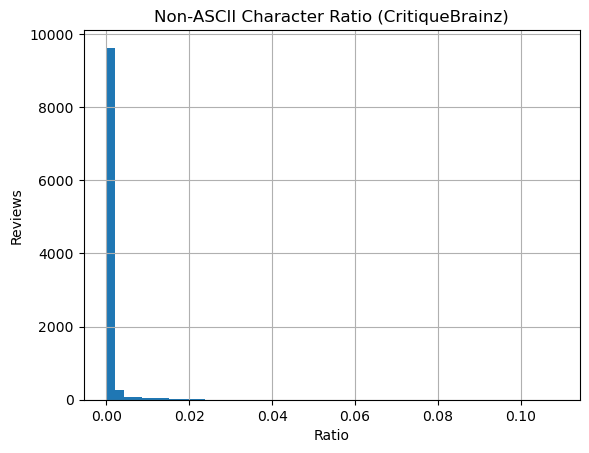

In [20]:
# Non-English review detection in CritiqueBrainz.
# Uses langdetect; falls back to non-ASCII character ratio as a proxy if unavailable.

cb = df[df["dataset"] == "critique_brainz"]["cleaned_text"].dropna()

try:
    from langdetect import detect, LangDetectException

    def safe_detect(text):
        try:
            return detect(text[:500])
        except LangDetectException:
            return "unknown"

    print("Sampling 2,000 CB reviews for language detection...")
    sample = cb.sample(min(2000, len(cb)), random_state=42)
    langs = sample.apply(safe_detect).value_counts()
    print(langs.head(15))
    non_english = langs[langs.index != "en"].sum()
    print(f"\nEstimated non-English: {non_english / len(sample) * 100:.1f}% of sample")

except ImportError:
    print("langdetect not installed — using non-ASCII ratio as proxy")
    non_ascii_ratio = cb.apply(lambda x: sum(ord(c) > 127 for c in x) / max(len(x), 1))
    threshold = 0.05
    likely_non_english = (non_ascii_ratio > threshold).sum()
    print(f"Reviews with >5% non-ASCII characters: {likely_non_english:,} ({likely_non_english/len(cb)*100:.1f}%)")
    non_ascii_ratio.hist(bins=50)
    plt.title("Non-ASCII Character Ratio (CritiqueBrainz)")
    plt.xlabel("Ratio")
    plt.ylabel("Reviews")
    plt.show()


Reviews under 200 chars (already filtered): confirmed 0 — cutoff applied in source notebooks
Reviews 200–500 chars (borderline):         491

Sample short reviews (200–300 chars):

1. Although this was 20 years ago, a few songs like "Swing, Swing" made it on to MVP Baseball. At least that's the high point. The rest of the CD is okay at best. I don't remember a lot of this CD. Then again, it's not my cup of tea.

2. This might be another case where the soundtrack is better than the film. Not to dump on the film, it's a pretty decent mid-90s comedy but there is no way the soundtrack should be as good as it is. A wonderful mix of R&B and hip-hop tracks, many unique to the soundtrack.

3. Pretty boring LP all round, this is the most easy of easy listening. Lastly a measly 31 minutes the entire thing just passes you by like a bland piece of artwork, it's not that the playing is bad its just so meh.

4. I'm pleasantly surprised with this album. can't remember the last time I heard a rap proj

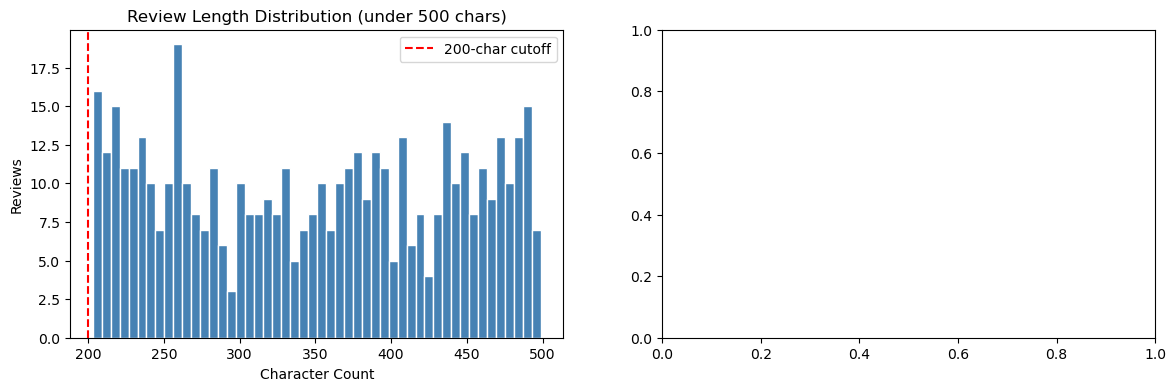

In [21]:
# Reviews at the low end of length — validate the 200-character minimum cutoff.

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

short = df[df["char_count"] < 500]
axes[0].hist(short["char_count"], bins=50, color="steelblue", edgecolor="white")
axes[0].axvline(200, color="red", linestyle="--", label="200-char cutoff")
axes[0].set(title="Review Length Distribution (under 500 chars)",
            xlabel="Character Count", ylabel="Reviews")
axes[0].legend()

print(f"Reviews under 200 chars (already filtered): confirmed 0 — cutoff applied in source notebooks")
print(f"Reviews 200–500 chars (borderline):         {len(short):,}")
print()
print("Sample short reviews (200–300 chars):")
borderline = df[(df["char_count"] >= 200) & (df["char_count"] < 300)]["cleaned_text"].sample(5, random_state=42)
for i, t in enumerate(borderline, 1):
    print(f"\n{i}. {t}")


In [22]:
# Sanity check: rating values should all fall within 0–5 after normalization.
print(df.groupby("dataset")["rating"].agg(["min","max"]))
print(f"\nRatings outside 0–5: {((df['rating'] < 0) | (df['rating'] > 5)).sum()}")


                  min  max
dataset                   
critique_brainz   1.0  5.0
pitchfork         0.0  5.0
resident_advisor  0.5  5.0

Ratings outside 0–5: 0


In [23]:
# Contraction artifact audit: how many reviews contain stripped apostrophe artifacts.
patterns = {
    "won't → wont": r"\bwont\b",
    "don't → don": r"\bdon\b(?!'t)",
    "I've → ve": r"\bve\b",
    "it's → its (ambiguous)": r"\bits\b",
    "wouldn't → wouldnt": r"\bwouldnt\b",
}
print("Contraction artifact prevalence:")
for label, pattern in patterns.items():
    count = df["cleaned_text"].str.contains(pattern, regex=True, na=False).sum()
    print(f"  {label:<35} {count:,} reviews ({count/len(df)*100:.1f}%)")


Contraction artifact prevalence:
  won't → wont                        71 reviews (0.1%)
  don't → don                         391 reviews (0.8%)
  I've → ve                           12,845 reviews (26.4%)
  it's → its (ambiguous)              33,052 reviews (68.0%)
  wouldn't → wouldnt                  7 reviews (0.0%)


In [24]:
# Preview model input: raw text vs. artist/album-prepended text.
# Helps decide whether to include metadata context before embedding.

sample = df.dropna(subset=["artist","album"]).sample(3, random_state=42)

for _, row in sample.iterrows():
    print("--- WITHOUT metadata ---")
    print(row["cleaned_text"][:300])
    print()
    print("--- WITH metadata ---")
    print(f"Artist: {row['artist']}. Album: {row['album']}. {row['cleaned_text'][:300]}")
    print("\n" + "="*80 + "\n")


--- WITHOUT metadata ---
On American Music Club's 1994 album San Francisco, Mark Eitzel declared that "the world is held together by the wind that blows through Gena Rowlands' hair." Rowlands, an accomplished actress, has never been an especially big star, but she's developed something of a cult fanbase for her work in TV d

--- WITH metadata ---
Artist: Gena Rowlands Band. Album: La Merde et Les Etoiles. On American Music Club's 1994 album San Francisco, Mark Eitzel declared that "the world is held together by the wind that blows through Gena Rowlands' hair." Rowlands, an accomplished actress, has never been an especially big star, but she's developed something of a cult fanbase for her work in TV d


--- WITHOUT metadata ---
Omega is a concept album of sorts from Robert Hood, the "godfather of minimal" and a founder member of the shadowy Underground Resistance, the political wing of Detroit's electronic music scene, of which he was appointed Minister of Information. In the vein of fe

In [25]:
# Train/val/test split exploration: split by artist to prevent leakage.
# Splitting by review or album would let the model learn artist-specific writing styles
# and overfit to source rather than musical content.

from sklearn.model_selection import train_test_split

unique_artists = df["artist_norm"].dropna().unique()
print(f"Total reviews:        {len(df):,}")
print(f"Unique artists:       {len(unique_artists):,}")
print(f"Reviews per artist:   mean={df.groupby('artist_norm').size().mean():.1f}, "
      f"median={df.groupby('artist_norm').size().median():.0f}, "
      f"max={df.groupby('artist_norm').size().max()}")
print()

# Simulate 80/10/10 split by artist
train_artists, temp   = train_test_split(unique_artists, test_size=0.2, random_state=42)
val_artists,   test_artists = train_test_split(temp, test_size=0.5, random_state=42)

train_df = df[df["artist_norm"].isin(train_artists)]
val_df   = df[df["artist_norm"].isin(val_artists)]
test_df  = df[df["artist_norm"].isin(test_artists)]
null_df  = df[df["artist_norm"].isna()]  # compilations — excluded from split

print(f"{'Split':<10} {'Artists':>10} {'Reviews':>10} {'% of total':>12}")
print("-" * 45)
for name, split, artists in [("Train", train_df, train_artists),
                               ("Val",   val_df,   val_artists),
                               ("Test",  test_df,  test_artists)]:
    print(f"{name:<10} {len(artists):>10,} {len(split):>10,} {len(split)/len(df)*100:>11.1f}%")
print(f"{'No artist':<10} {'—':>10} {len(null_df):>10,} {len(null_df)/len(df)*100:>11.1f}%")


Total reviews:        48,639
Unique artists:       21,360
Reviews per artist:   mean=2.3, median=1, max=1553

Split         Artists    Reviews   % of total
---------------------------------------------
Train          17,088     39,145        80.5%
Val             2,136      4,779         9.8%
Test            2,136      4,505         9.3%
No artist           —        210         0.4%


In [26]:
# How many positive training pairs (same album, different source) fall in each split?
# These are the fine-tuning signal for contrastive learning.

cross_source = (
    df.dropna(subset=["artist_norm","album_norm"])
    .groupby(["artist_norm","album_norm"])
    .filter(lambda x: x["dataset"].nunique() > 1)
    .groupby(["artist_norm","album_norm"])
)

pairs_in_split = {"train": 0, "val": 0, "test": 0, "split": 0}
for (artist, album), group in cross_source:
    datasets = group["dataset"].unique()
    if artist in train_artists:
        pairs_in_split["train"] += len(datasets) * (len(datasets) - 1) // 2
    elif artist in val_artists:
        pairs_in_split["val"]   += len(datasets) * (len(datasets) - 1) // 2
    elif artist in test_artists:
        pairs_in_split["test"]  += len(datasets) * (len(datasets) - 1) // 2
    else:
        pairs_in_split["split"] += 1

total_pairs = sum(pairs_in_split.values())
print(f"Total cross-source positive pairs: {total_pairs:,}")
print()
for split, count in pairs_in_split.items():
    print(f"  {split:<10} {count:>6,} pairs  ({count/total_pairs*100:.1f}%)")


Total cross-source positive pairs: 3,653

  train       2,924 pairs  (80.0%)
  val           398 pairs  (10.9%)
  test          331 pairs  (9.1%)
  split           0 pairs  (0.0%)


In [27]:
# Deep learning overfitting risk assessment.
# Rule of thumb for fine-tuning sentence transformers:
# ~10,000+ training pairs is generally sufficient; <1,000 risks overfitting.

print("Fine-tuning data assessment:")
print(f"  Positive pairs in training set: {pairs_in_split['train']:,}")
print()
print("With in-batch negatives (standard for contrastive learning):")
batch_size = 32
effective_negatives = batch_size - 1
effective_pairs_per_batch = batch_size * effective_negatives
print(f"  Batch size {batch_size} → {effective_negatives} negatives per anchor per batch")
print(f"  Effective training signal per batch: {effective_pairs_per_batch:,} pairs")
print()

train_reviews = len(train_df)
print(f"Zero-shot embedding (no fine-tuning):")
print(f"  All {train_reviews:,} training reviews used for embedding — no overfitting risk")
print()
print(f"If fine-tuning: {pairs_in_split['train']:,} positive pairs available")
if pairs_in_split['train'] >= 10000:
    print("  ✓ Above 10,000-pair threshold — sufficient for fine-tuning")
elif pairs_in_split['train'] >= 1000:
    print("  ⚠ Between 1,000–10,000 pairs — fine-tuning feasible but monitor closely")
else:
    print("  ✗ Under 1,000 pairs — high overfitting risk, stick with zero-shot")


Fine-tuning data assessment:
  Positive pairs in training set: 2,924

With in-batch negatives (standard for contrastive learning):
  Batch size 32 → 31 negatives per anchor per batch
  Effective training signal per batch: 992 pairs

Zero-shot embedding (no fine-tuning):
  All 39,145 training reviews used for embedding — no overfitting risk

If fine-tuning: 2,924 positive pairs available
  ⚠ Between 1,000–10,000 pairs — fine-tuning feasible but monitor closely


In [28]:
print(df.groupby("artist_norm").size().sort_values(ascending=False).head(10))


artist_norm
various artists    1553
various             396
matt johnson         47
david bowie          43
r.e.m.               40
bob dylan            36
the beatles          36
four tet             32
neil young           31
autechre             29
dtype: int64


## Preprocessing Notes

### 1. Inclusion / Exclusion Criteria

**Exclude:**
- Event and live reviews (already removed from RA dataset) — no album to recommend against
- Reviews under 200 characters (already filtered in all source notebooks) — insufficient signal for embedding
- Intra-source duplicates: 217 artist/album pairs with multiple reviews within the same source (236 excess reviews). Keep the longest review per artist/album/source combination.

**Include with caveats:**
- VA/compilation reviews (artist = null, ~210 reviews) — valid review text for embedding but cannot be queried by artist name
- Reviews without ratings (9,126, mostly CritiqueBrainz) — ratings not required for similarity-based embedding
- Multi-album/split reviews — messy album fields but review text is still embeddable

**Pending:**
- CritiqueBrainz BBC boilerplate removal — after stripping, reviews that fall below 200 characters should be dropped automatically
- "Various" and "Various Artists" should be normalized to a single null-equivalent label

**Not a concern:**
- Non-English reviews: only 3 reviews (0.0%) flagged by non-ASCII proxy — no filtering needed

---

### 2. Preprocessing Transformations Required

**Already done in source notebooks:**
- HTML tag stripping
- Unicode normalization (whitespace, non-breaking spaces, soft hyphens)
- Whitespace normalization
- Minimum length filtering (200 characters)

**Still required before embedding:**
- CritiqueBrainz boilerplate removal (BBC navigation text fragments)
- Deduplication (keep longest review per artist/album/source)
- Normalize "Various" → null to match existing null artist entries
- Normalize genre tag capitalization (`.str.title()`) for any genre-based filtering

**Model input formatting:**
- Prepend artist and album metadata to each review before embedding:
  `"Artist: {artist}. Album: {album}. {review_text}"`
  Necessary because Pitchfork reviews frequently open with extended cultural references before naming the album being reviewed — without the prefix, embeddings risk being anchored to the wrong artist
- Jina v2 requires a `"passage: "` task prefix for symmetric similarity tasks:
  `"passage: Artist: {artist}. Album: {album}. {review_text}"`
- Contraction handling: not required — Jina v2's subword tokenizer handles contractions natively

---

### 3. Train / Validation / Test Split

**Split strategy: by artist** (not by review or album) to prevent data leakage. If albums by the same artist appeared in both training and evaluation sets, the model could learn artist-specific language patterns rather than generalizing across musical content.

| Split | Artists | Reviews | % of total |
|-------|---------|---------|------------|
| Train | 17,088 | 39,145 | 80.5% |
| Val | 2,136 | 4,779 | 9.8% |
| Test | 2,136 | 4,505 | 9.3% |
| No artist (compilations) | — | 210 | 0.4% |

**Cross-source positive pairs for fine-tuning:**
- Total: 3,653 pairs (same album reviewed by multiple sources)
- Training set: 2,924 pairs

**Overfitting assessment:**

*Zero-shot (recommended starting point):* No training step, no overfitting risk. All 39,145 training reviews used directly for embedding.

*Fine-tuning:* 2,924 positive training pairs falls in the caution zone (1,000–10,000). Fine-tuning is feasible but requires early stopping and close monitoring of validation loss. Not recommended until zero-shot results have been evaluated as a baseline.

**Notable:** median reviews per artist = 1. The dataset is extremely long-tailed — most artists appear only once, meaning the model must generalize from language alone rather than artist-level patterns. This strongly supports the semantic similarity approach.
